In [1]:
import pandas as pd

In [ ]:
X = pd.read_csv('features.csv')
y = pd.read_csv('targets.csv')

X = X.drop(columns=['Unnamed: 0'])


In [9]:
display(X.select_dtypes(include=['int64']).describe())

,Duration,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age,Number of existing credits at this bank,Number of people being liable to provide maintenance for
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


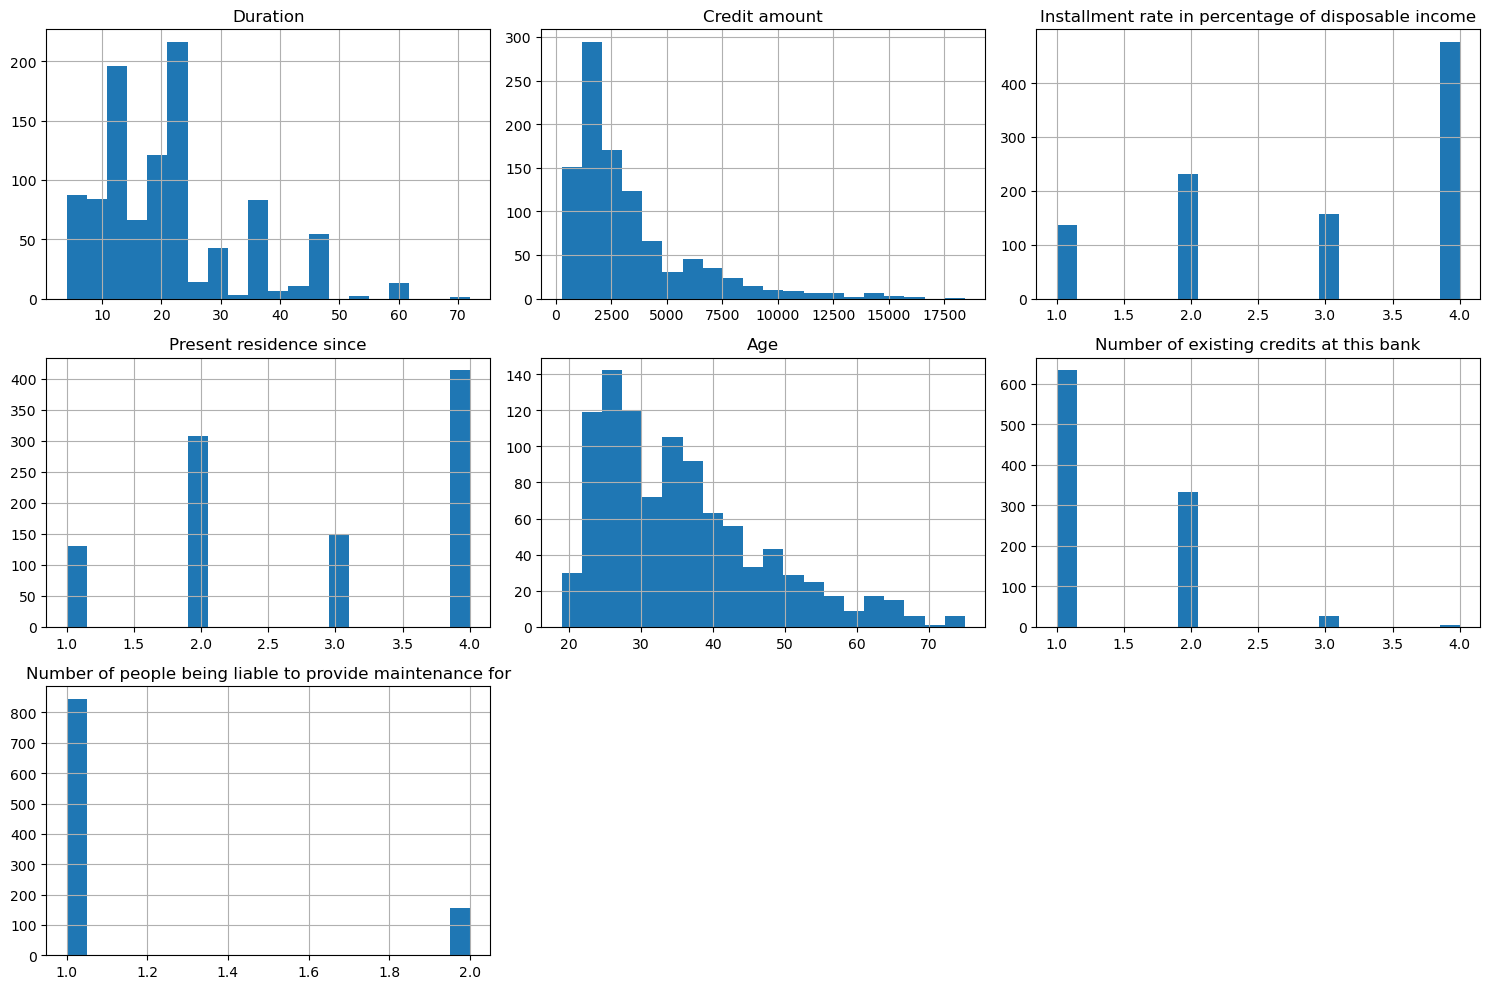

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = X.select_dtypes(include=['int64']).columns

X[numerical_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [14]:
categorical_cols = X.select_dtypes(exclude=['int64']).columns

In [15]:
import numpy as np

C:\Users\bakru_b9pmn2k\AppData\Local\Temp\ipykernel_20876\1804287456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\bakru_b9pmn2k\AppData\Local\Temp\ipykernel_20876\1804287456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\bakru_b9pmn2k\AppData\Local\Temp\ipykernel_20876\1804287456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\bakru_b9pmn2k\AppData\Local\Temp\ipykernel_20876\1804287456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

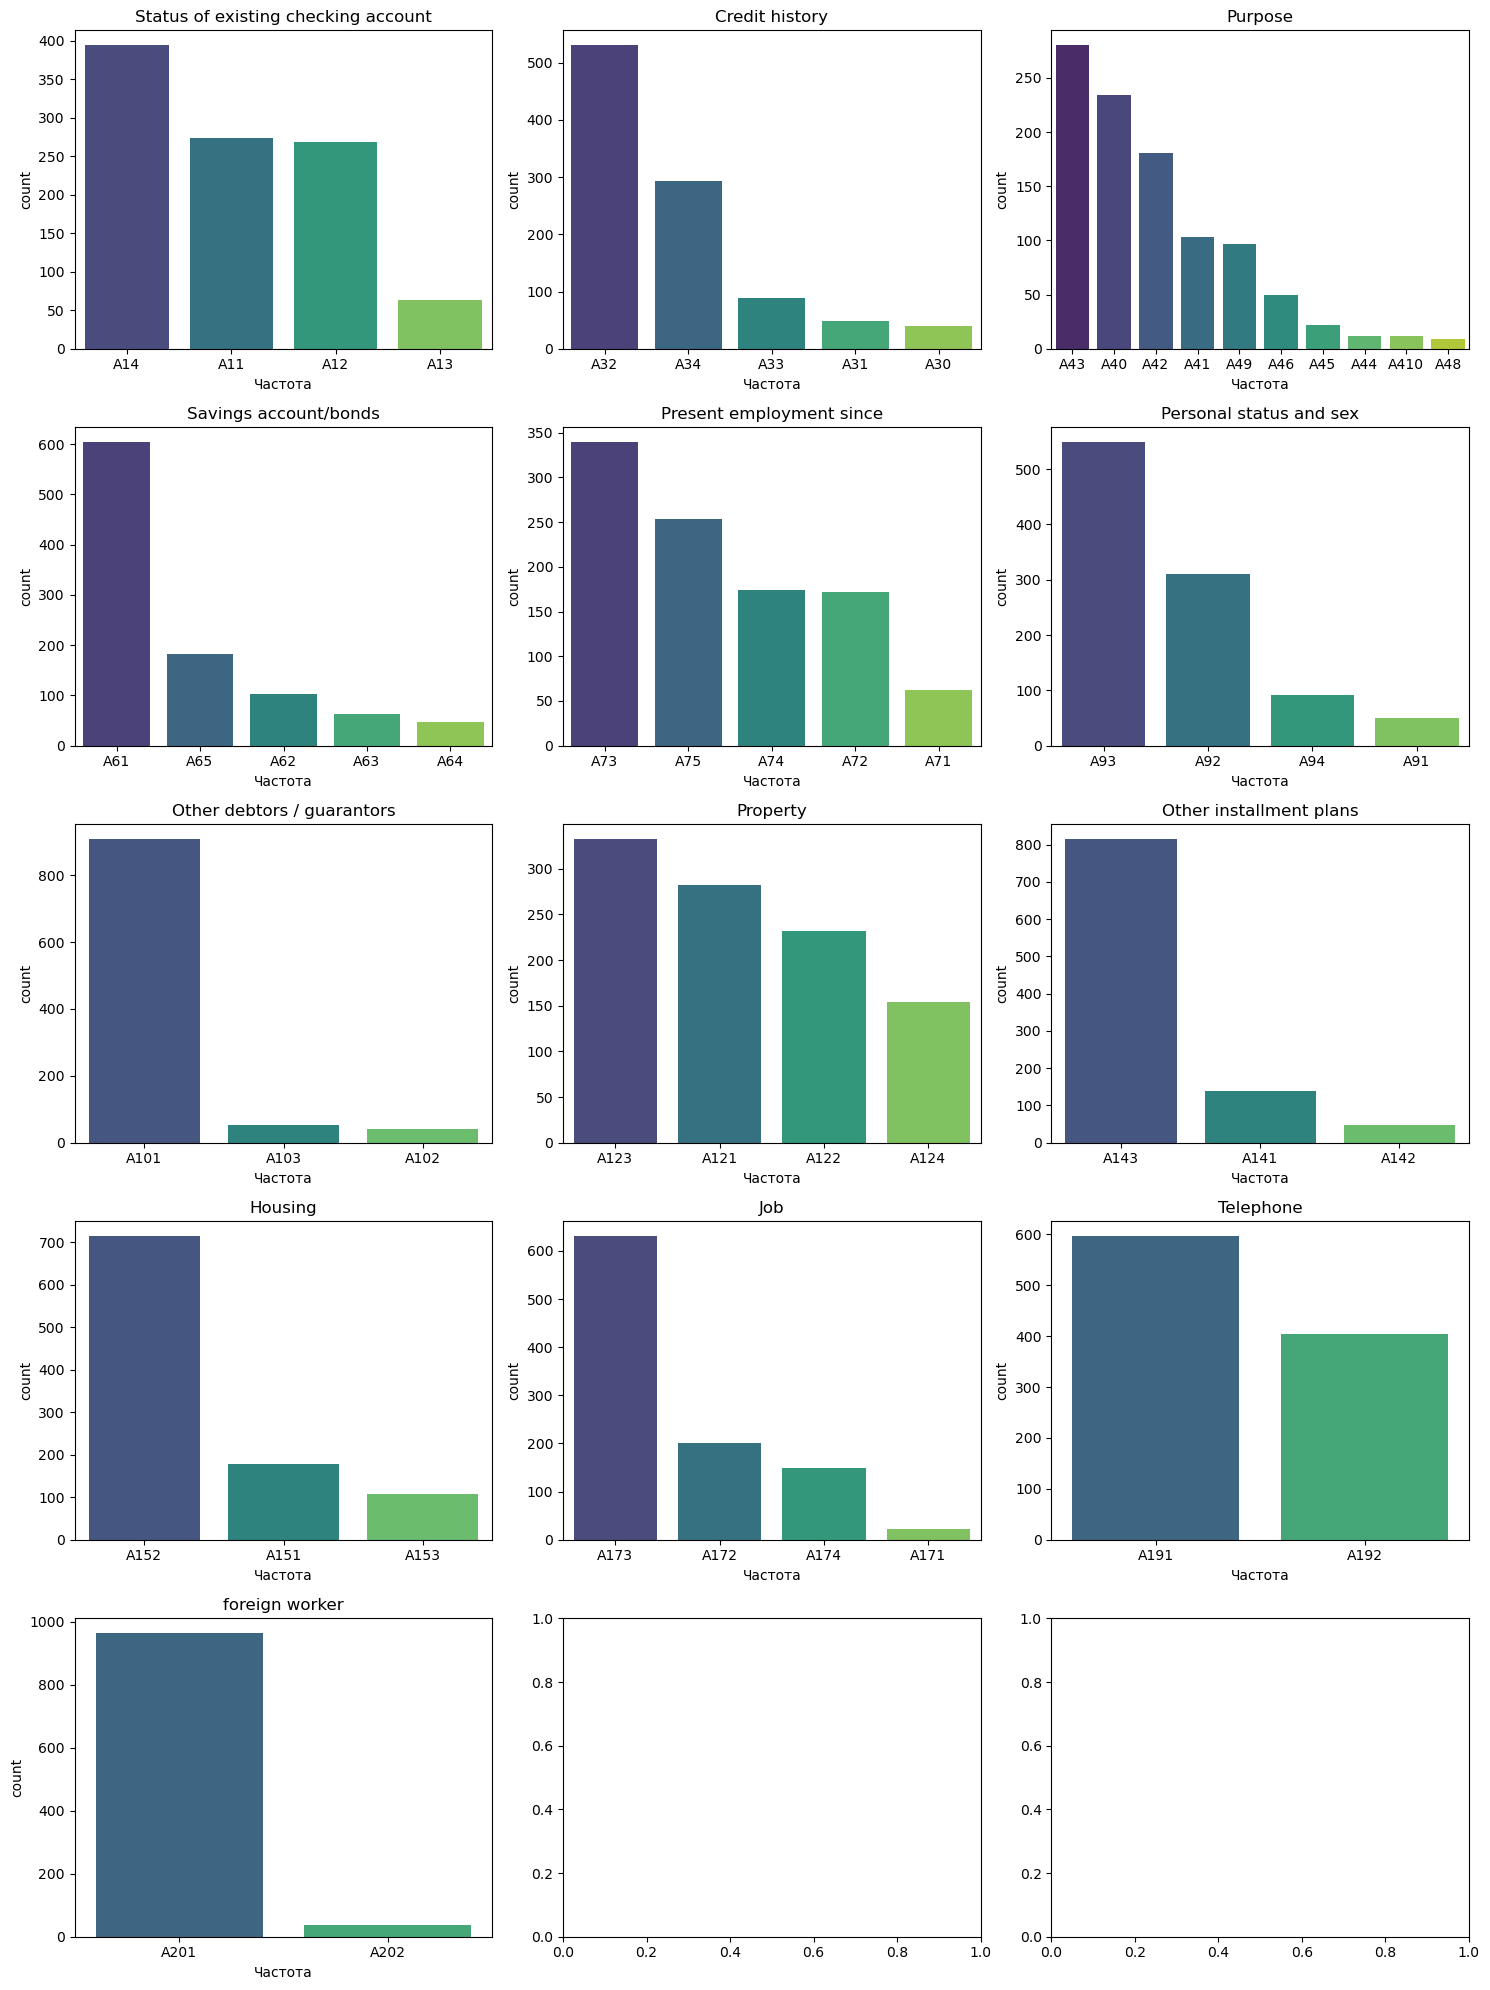

In [21]:
n_cols = 3 
n_rows = int(np.ceil(len(categorical_cols) / n_cols)) 
n_plots = len(categorical_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(categorical_cols):
    ax = axes[i] 
    
    sns.countplot(
        x=X[column],
        data=X,
        order=X[column].value_counts().index,
        ax=ax,
        palette="viridis" 
    )
    
    ax.set_title(f'{column}', fontsize=12) 
    ax.set_xlabel('Частота') 
    

plt.tight_layout()
plt.show()

In [ ]:
cat_cols = X.select_dtypes(include='object').columns

In [27]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoded = ohe.fit_transform(X[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=X.index)

X_encoded = pd.concat([X.drop(columns=cat_cols), encoded_df], axis=1)
X_encoded.head(2)


,Duration,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Status of existing checking account_A12,Status of existing checking account_A13,Status of existing checking account_A14,...,Property_A124,Other installment plans_A142,Other installment plans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,foreign worker_A202
0,6,1169,4,4,67,2,1,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,48,5951,2,2,22,1,1,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [28]:
X_encoded.to_csv('features_encoded.csv')